In [1]:
from deepface import DeepFace
import os
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide tensorflow logs

In [3]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Virat Kohli.jpg"

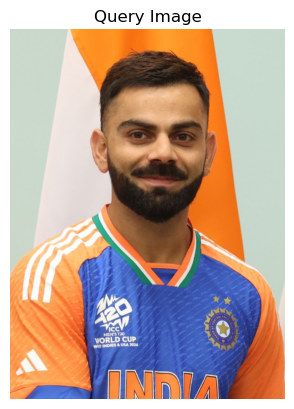

In [4]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

Detecting face using RetinaFace...


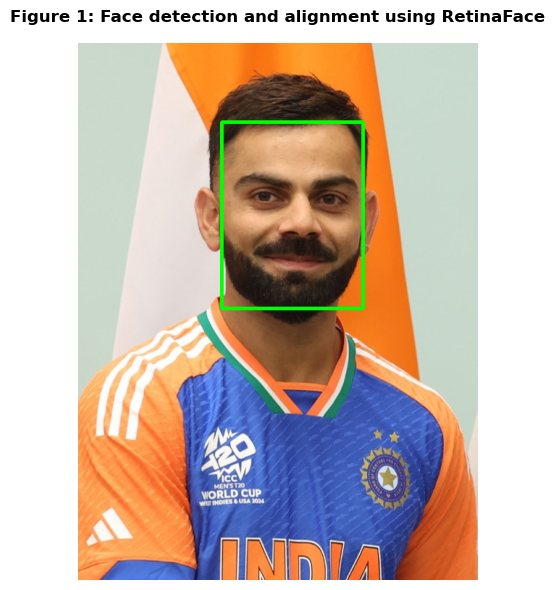

Figure 1 saved successfully as 'figure1_face_detection.png'!


In [3]:
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

# Tomar jekono ekta test image-er path ekhane dao
img_path = "test_image/Virat Kohli.jpg" # Eta change kore tomar chobir naam/path dio

# OpenCV diye image read kora (BGR theke RGB te convert kora jate color thik thake)
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# RetinaFace backend use kore face extract kora
print("Detecting face using RetinaFace...")
faces = DeepFace.extract_faces(img_path=img_path, detector_backend='retinaface', enforce_detection=False)

# Detect kora face-er charpashe box aanka
for face_obj in faces:
    facial_area = face_obj['facial_area']
    x = facial_area['x']
    y = facial_area['y']
    w = facial_area['w']
    h = facial_area['h']
    
    # Green color-er rectangle aanka (thickness=3)
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 3)

# Chobita dekhano ar save kora
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off') # X ar Y axis-er number gulo hide korar jonno
plt.title('Figure 1: Face detection and alignment using RetinaFace', fontsize=12, fontweight='bold', pad=15)

# High-resolution e save kora jate magazine-e fete na jay
plt.tight_layout()
plt.savefig('figure1_face_detection.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 1 saved successfully as 'figure1_face_detection.png'!")

In [5]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="VGG-Face",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-10 11:56:14 - Searching test_image/Virat Kohli.jpg in 38 length datastore
26-02-10 11:56:19 - find function duration 25.87289834022522 seconds


In [6]:
threshold = 0.45  # VGG-Face threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Match found: Virat Kohli
Score: 0.959


In [7]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Stranger.jpg"

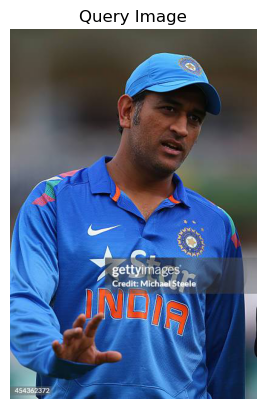

In [8]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [9]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="VGG-Face",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-10 11:56:57 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 11:56:58 - find function duration 14.017305612564087 seconds


In [10]:
threshold = 0.45  # VGG-Face threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Stranger detected


In [11]:
test_data = {}

for file in os.listdir("test_image"):
    if file.lower().endswith((".jpg", ".jpeg", ".png",".jpe")):
        name = os.path.splitext(file)[0]
        test_data[name] = f"test_image/{file}"

print(test_data)


{'Droupadi Murmu': 'test_image/Droupadi Murmu.jpg', 'Kiran Dutta': 'test_image/Kiran Dutta.png', 'PM Modi': 'test_image/PM Modi.jpg', 'Shreya Ghoshal': 'test_image/Shreya Ghoshal.jpg', 'Stranger': 'test_image/Stranger.jpg', 'Stranger1': 'test_image/Stranger1.jpg', 'Stranger2': 'test_image/Stranger2.jpg', 'Stranger3': 'test_image/Stranger3.jpg', 'Stranger4': 'test_image/Stranger4.jpg', 'Virat kohli': 'test_image/Virat kohli.jpg'}


In [19]:
correct = 0
total = 0
threshold = 0.45

known_people = set(os.listdir("database"))  

for label, img in test_data.items():

    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="VGG-Face",
        detector_backend="retinaface",
        enforce_detection=False
    )

    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]

        if distance < threshold:
            predicted = os.path.basename(os.path.dirname(best["identity"]))
        else:
            predicted = "stranger"

    print(f"True: {label} | Predicted: {predicted}")

    # normalize label
    true_label = label if label in known_people else "stranger"

    if predicted == true_label:
        correct += 1

    total += 1

accuracy = correct / total
print("\nAccuracy:", round(accuracy * 100, 2), "%")


26-02-10 12:23:30 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:23:31 - find function duration 15.1151704788208 seconds
True: Droupadi Murmu | Predicted: Droupadi Murmu
26-02-10 12:23:45 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 12:23:45 - find function duration 13.809045553207397 seconds
True: Kiran Dutta | Predicted: Kiran Dutta
26-02-10 12:23:57 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 12:23:57 - find function duration 12.320853233337402 seconds
True: PM Modi | Predicted: PM Modi
26-02-10 12:24:11 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 12:24:11 - find function duration 14.114920377731323 seconds
True: Shreya Ghoshal | Predicted: Shreya Ghoshal
26-02-10 12:24:24 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 12:24:24 - find function duration 12.977132558822632 seconds
True: Stranger | Predicted: stranger
26-02-10 12:24:35 - Searching test_image

In [20]:
# FAR: stranger predicted as known
false_accept = 0
total_stranger = 0

for label, img in test_data.items():
    true_label = label if label in known_people else "stranger"
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="VGG-Face",
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    if true_label == "stranger":
        total_stranger += 1
        if predicted != "stranger":
            false_accept += 1

far = false_accept / total_stranger if total_stranger > 0 else 0
print("False Acceptance Rate (FAR):", round(far * 100, 2), "%")

26-02-10 12:26:00 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:26:01 - find function duration 15.12490177154541 seconds
26-02-10 12:26:14 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 12:26:14 - find function duration 13.417832851409912 seconds
26-02-10 12:26:28 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 12:26:29 - find function duration 14.337872982025146 seconds
26-02-10 12:26:41 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 12:26:41 - find function duration 12.586726427078247 seconds
26-02-10 12:26:53 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 12:26:54 - find function duration 12.183928966522217 seconds
26-02-10 12:27:04 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-10 12:27:04 - find function duration 10.478710651397705 seconds
26-02-10 12:27:14 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-10 12:27:15 - find f

In [21]:
# FRR: known person predicted as stranger
false_reject = 0
total_known = 0

for label, img in test_data.items():
    true_label = label if label in known_people else "stranger"
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name='VGG-Face',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    if true_label != "stranger":
        total_known += 1
        if predicted == "stranger":
            false_reject += 1

frr = false_reject / total_known if total_known > 0 else 0
print("False Rejection Rate (FRR):", round(frr * 100, 2), "%")

26-02-10 12:28:16 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:28:16 - find function duration 16.752665281295776 seconds
26-02-10 12:28:31 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 12:28:31 - find function duration 14.704540252685547 seconds
26-02-10 12:28:43 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 12:28:43 - find function duration 12.312396764755249 seconds
26-02-10 12:28:56 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 12:28:56 - find function duration 12.694101095199585 seconds
26-02-10 12:29:08 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 12:29:08 - find function duration 12.028277397155762 seconds
26-02-10 12:29:18 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-10 12:29:19 - find function duration 10.719399213790894 seconds
26-02-10 12:29:29 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-10 12:29:30 - find 

26-02-10 12:30:31 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:30:32 - find function duration 15.911935567855835 seconds
26-02-10 12:30:45 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 12:30:46 - find function duration 13.456108570098877 seconds
26-02-10 12:30:58 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 12:30:58 - find function duration 12.697501420974731 seconds
26-02-10 12:31:11 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 12:31:11 - find function duration 12.638953447341919 seconds
26-02-10 12:31:23 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 12:31:23 - find function duration 12.209218502044678 seconds
26-02-10 12:31:33 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-10 12:31:34 - find function duration 10.571449041366577 seconds
26-02-10 12:31:44 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-10 12:31:45 - find 

<Figure size 1200x800 with 0 Axes>

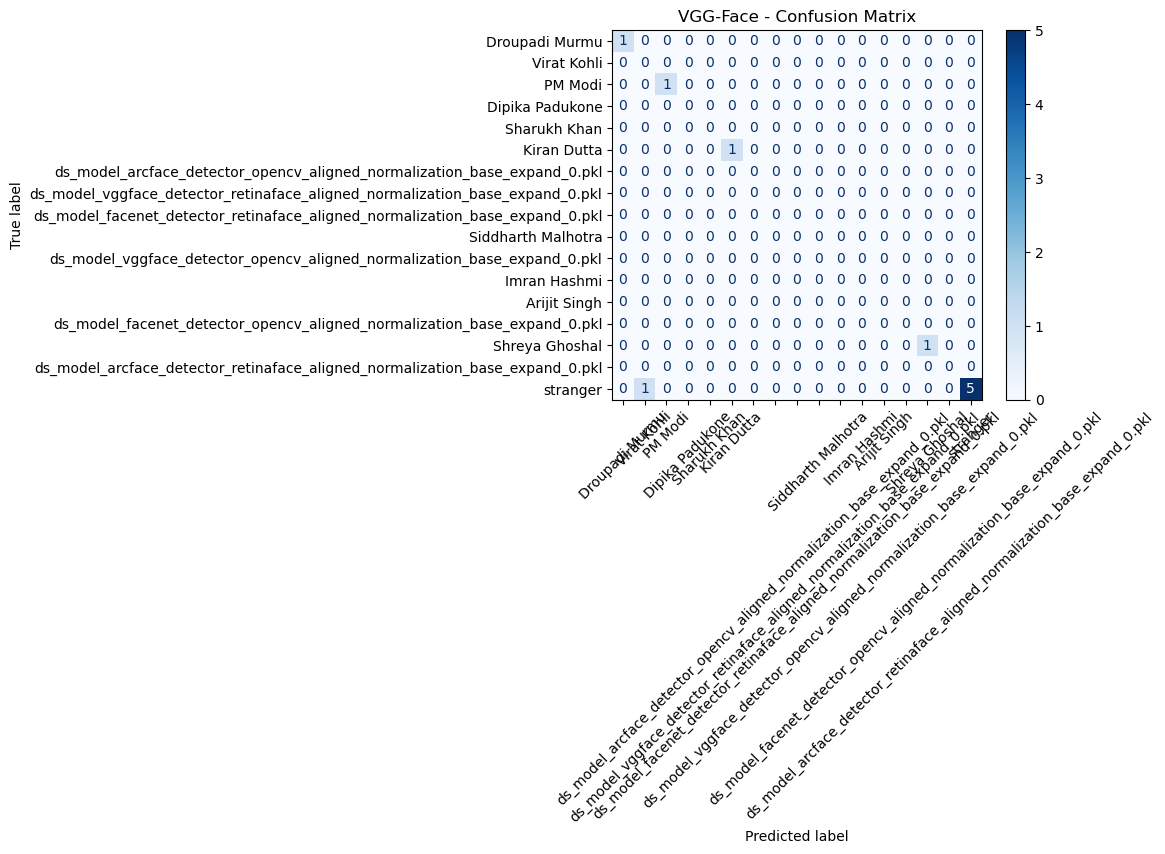

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_name = "VGG-Face"
threshold = 0.45

y_true = []
y_pred = []

known_people = set(os.listdir("database"))

for label, img_path in test_data.items():
    results = DeepFace.find(
        img_path=img_path,
        db_path="database",
        model_name='VGG-Face',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    true_label = label if label in known_people else "stranger"

    y_true.append(true_label)
    y_pred.append(predicted)

labels = list(known_people) + ["stranger"]
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(12,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title(f"{model_name} - Confusion Matrix")
plt.show()

26-02-10 12:34:58 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:34:59 - find function duration 16.253960132598877 seconds
26-02-10 12:35:14 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 12:35:15 - find function duration 15.763352632522583 seconds
26-02-10 12:35:27 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 12:35:27 - find function duration 12.899309396743774 seconds
26-02-10 12:35:41 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 12:35:41 - find function duration 13.534997701644897 seconds
26-02-10 12:35:53 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 12:35:54 - find function duration 12.538274765014648 seconds
26-02-10 12:36:04 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-10 12:36:04 - find function duration 10.65010404586792 seconds
26-02-10 12:36:16 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-10 12:36:16 - find f

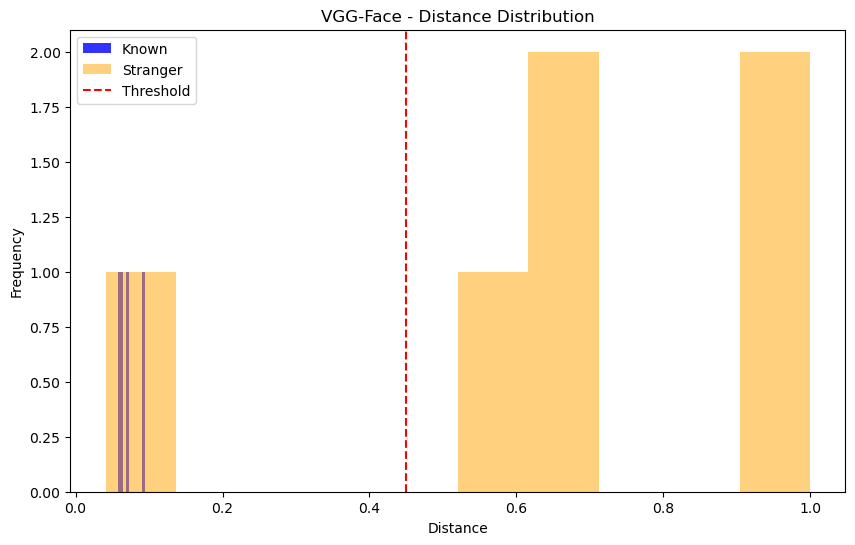

In [24]:
import matplotlib.pyplot as plt
import numpy as np

model_name = "VGG-Face"
threshold = 0.45

known_distances = []
stranger_distances = []

for label, img in test_data.items():
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name='VGG-Face',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        distance = 1.0  # large distance for stranger
    else:
        distance = df.iloc[0]["distance"]

    if label in os.listdir("database"):
        known_distances.append(distance)
    else:
        stranger_distances.append(distance)

plt.figure(figsize=(10,6))

plt.hist(known_distances, bins=10, alpha=0.8, label="Known", color="blue")
plt.hist(stranger_distances, bins=10, alpha=0.5, label="Stranger", color="orange")

plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.title("VGG-Face - Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [23]:
from deepface import DeepFace
import time

test_images = {
    'Droupadi Murmu': 'test_image/Droupadi Murmu.jpg',
    'Kiran Dutta': 'test_image/Kiran Dutta.png',
    'PM Modi': 'test_image/PM Modi.jpg',
    'Shreya Ghoshal': 'test_image/Shreya Ghoshal.jpg',
    'Stranger': 'test_image/Stranger.jpg',
    'Stranger1': 'test_image/Stranger1.jpg',
    'Stranger2': 'test_image/Stranger2.jpg',
    'Stranger3': 'test_image/Stranger3.jpg',
    'Stranger4': 'test_image/Stranger4.jpg',
    'Virat kohli': 'test_image/Virat kohli.jpg'
}

db_path = "database"  # your database folder

inference_times = []

# Optional warm-up
_ = DeepFace.find(img_path=list(test_images.values())[0],
                  db_path=db_path,
                  model_name="VGG-Face",  # or current model
                  detector_backend="retinaface",
                  enforce_detection=False)

for name, img_path in test_images.items():
    start_time = time.time()
    _ = DeepFace.find(img_path=img_path,
                      db_path=db_path,
                      model_name="VGG-Face",  # or current model
                      detector_backend="retinaface",
                      enforce_detection=False)
    end_time = time.time()
    t = end_time - start_time
    inference_times.append(t)
    print(f"Inference time for {name}: {t:.4f} sec")

avg_time = sum(inference_times) / len(inference_times)
print(f"\nAverage inference time for this model: {avg_time:.4f} sec")


26-02-10 12:32:36 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:32:36 - find function duration 16.26539921760559 seconds
26-02-10 12:32:51 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 12:32:52 - find function duration 15.57486891746521 seconds
Inference time for Droupadi Murmu: 15.5772 sec
26-02-10 12:33:06 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 12:33:06 - find function duration 13.975159168243408 seconds
Inference time for Kiran Dutta: 13.9774 sec
26-02-10 12:33:18 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 12:33:18 - find function duration 12.31132698059082 seconds
Inference time for PM Modi: 12.3157 sec
26-02-10 12:33:31 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 12:33:31 - find function duration 13.008943319320679 seconds
Inference time for Shreya Ghoshal: 13.0114 sec
26-02-10 12:33:43 - Searching test_image/Stranger.jpg in 38 length dat

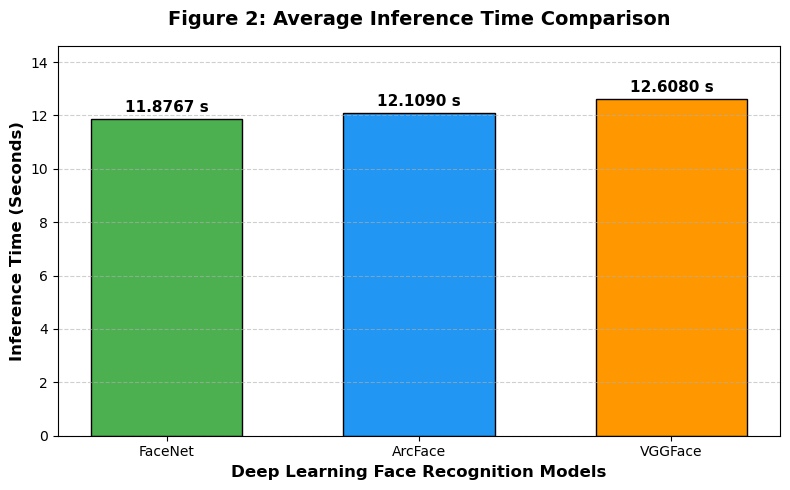

In [4]:
import matplotlib.pyplot as plt

# Tomar notebook theke paowa exact data
models = ['FaceNet', 'ArcFace', 'VGGFace']
inference_times = [11.8767, 12.1090, 12.6080] # In seconds
colors = ['#4CAF50', '#2196F3', '#FF9800'] # Green, Blue, Orange for variety

# Figure size setup
plt.figure(figsize=(8, 5))
bars = plt.bar(models, inference_times, color=colors, edgecolor='black', width=0.6)

# Bar-er upor exact time value gulo lekhar jonno
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.15, f'{yval:.4f} s', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Chart styling
plt.title('Figure 2: Average Inference Time Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Deep Learning Face Recognition Models', fontsize=12, fontweight='bold')
plt.ylabel('Inference Time (Seconds)', fontsize=12, fontweight='bold')
plt.ylim(0, max(inference_times) + 2) # Uporer dike ektu faka jaiga rakhar jonno
plt.grid(axis='y', linestyle='--', alpha=0.6)

# High-resolution image hishebe save kora
plt.tight_layout()
plt.savefig('inference_time_comparison.png', dpi=300)
plt.show()

Error: Figure 3(a) er image path gulo thik nei.


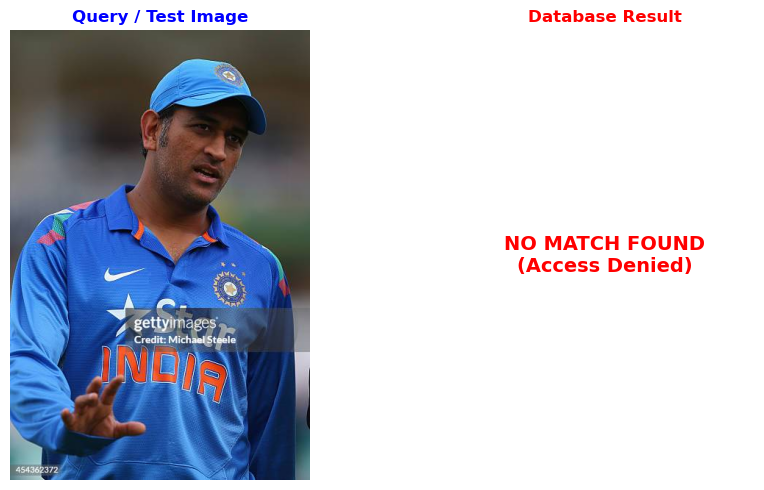

Figure 3(b) saved as 'figure3b_mismatch.png'


In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_image_rgb(img_path):
    """OpenCV image ke RGB te convert korar helper function"""
    img = cv2.imread(img_path)
    if img is not None:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None

# ==========================================
# Figure 3(a): SUCCESSFUL MATCH
# ==========================================
# Tomar path gulo ekhane update koro
query_match_path = "test_image/Virat Kohli.jpg"      # Jeta match korte chaicho
matched_db_path = "database/Virat Kohli.jpg"   # Jeta database theke match hoyeche

img_query = show_image_rgb(query_match_path)
img_matched = show_image_rgb(matched_db_path)

if img_query is not None and img_matched is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Left Side: Query Image
    axes[0].imshow(img_query)
    axes[0].axis('off')
    axes[0].set_title('Query / Test Image', fontsize=12, fontweight='bold', color='blue')
    
    # Right Side: Matched Image
    axes[1].imshow(img_matched)
    axes[1].axis('off')
    axes[1].set_title('Matched Image (from Database)', fontsize=12, fontweight='bold', color='green')
    
    # Main Caption
    plt.suptitle('Figure 3(a): Successful face recognition match from the custom database.', 
                 fontsize=14, fontweight='bold', y=0.05) # y parameter ta text ke niche anar jonno
    
    plt.tight_layout()
    plt.savefig('figure3a_match.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figure 3(a) saved as 'figure3a_match.png'")
else:
    print("Error: Figure 3(a) er image path gulo thik nei.")


# ==========================================
# Figure 3(b): UNSUCCESSFUL MATCH (MISMATCH)
# ==========================================
# Emon ekta chobir path dao jeta database e nei
query_mismatch_path = "test_image/Stranger.jpg" 

img_mismatch_query = show_image_rgb(query_mismatch_path)

if img_mismatch_query is not None:
    fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
    
    # Left Side: Query Image
    axes2[0].imshow(img_mismatch_query)
    axes2[0].axis('off')
    axes2[0].set_title('Query / Test Image', fontsize=12, fontweight='bold', color='blue')
    
    # Right Side: Blank canvas with "Mismatch" text
    blank_image = np.ones((img_mismatch_query.shape[0], img_mismatch_query.shape[1], 3), dtype=np.uint8) * 255 # White background
    axes2[1].imshow(blank_image)
    axes2[1].axis('off')
    axes2[1].set_title('Database Result', fontsize=12, fontweight='bold', color='red')
    axes2[1].text(0.5, 0.5, 'NO MATCH FOUND\n(Access Denied)', 
                  horizontalalignment='center', verticalalignment='center', 
                  transform=axes2[1].transAxes, fontsize=14, fontweight='bold', color='red')
    
    # Main Caption
   
    
    plt.tight_layout()
    plt.savefig('figure3b_mismatch.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figure 3(b) saved as 'figure3b_mismatch.png'")
else:
    print("Error: Figure 3(b) er query image path thik nei.")

Images found: ['IPL_2021.jpg', 'Virat_Kohli_in_PMO_New_Delhi.jpg', 'Virat_Kohli_with_AudiQ7.png']


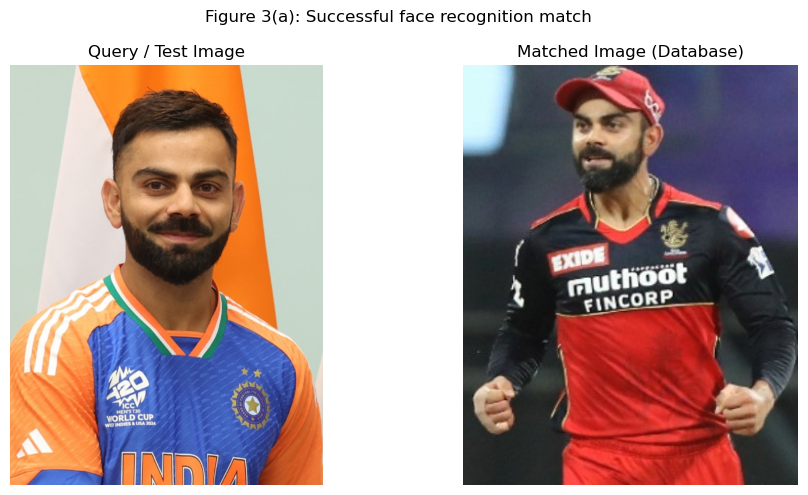

In [26]:
import cv2
import matplotlib.pyplot as plt
import os

def show_image_rgb(path):
    img = cv2.imread(path)
    if img is not None:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None


query_match_path = "test_image/virat.jpg"
db_folder = "database/virat_db"

# only image files
files = [f for f in os.listdir(db_folder) 
         if f.lower().endswith(('.png','.jpg','.jpeg'))]

print("Images found:", files)

if len(files) == 0:
    print("Database folder e kono image nei")
    exit()

matched_db_path = os.path.join(db_folder, files[0])

img_query = show_image_rgb(query_match_path)
img_matched = show_image_rgb(matched_db_path)

if img_query is None or img_matched is None:
    print("Image load hoyni, path check koro")
    exit()


fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(img_query)
axes[0].axis("off")
axes[0].set_title("Query / Test Image")

axes[1].imshow(img_matched)
axes[1].axis("off")
axes[1].set_title("Matched Image (Database)")

plt.suptitle("Figure 3(a): Successful face recognition match")

plt.tight_layout()
plt.savefig("figure3a_match.png", dpi=300)
plt.show()

In [25]:
import os
print(os.listdir("database/virat_db"))

['.ipynb_checkpoints', 'images.jpe', 'IPL_2021.jpg', 'Virat_Kohli_in_PMO_New_Delhi.jpg', 'Virat_Kohli_with_AudiQ7.png']
